In [12]:
%config InlineBackend.figure_formats=['svg']
from os import listdir
from matplotlib import pyplot as plt, ticker as mticker
import numpy as np
import matplotlib as mpl
from adjustText import adjust_text

#mpl.rcParams["text.usetex"] = True

In [13]:
Average = [7.08211260e+06, 5.15056588e+06, 3.72436481e+06, 2.71572185e+06,
            1.97472603e+06, 1.42408918e+06, 1.02232317e+06, 7.32125310e+05,
            5.24090642e+05, 3.74998464e+05, 2.66916821e+05, 1.89078950e+05,
            1.35700261e+05, 9.74077327e+04, 6.94691976e+04, 4.90518881e+04,
            3.50311232e+04, 2.50723929e+04, 1.77261578e+04, 1.26385561e+04,
            9.03448510e+03, 6.34776305e+03, 4.44228612e+03, 3.11561879e+03,
            2.20105919e+03, 1.55472974e+03, 1.10119877e+03, 7.74547737e+02,
            5.46214434e+02, 3.86814856e+02, 2.77270797e+02, 1.97954232e+02,
            1.39667657e+02, 9.96796628e+01, 7.12159618e+01, 5.03875460e+01,
            3.56871128e+01, 2.54771649e+01, 1.80622346e+01, 1.27380046e+01,
            9.02367143e+00, 6.40704597e+00, 4.54269070e+00, 3.20272751e+00,
            2.26309906e+00]

dB = [ 7.,   7.5,  8.,   8.5,  9.,   9.5, 10.,  10.5, 11.,  11.5, 12.,  12.5, 13.,  13.5,
       14.,  14.5, 15.,  15.5, 16.,  16.5, 17.,  17.5, 18.,  18.5, 19.,  19.5, 20.,  20.5,
       21.,  21.5, 22.,  22.5, 23.,  23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5,
       28.,  28.5, 29. ]

In [14]:
#Thermal
config_thermal = {'MAX 1D 1D.npy' : {'Name' : 'Max', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,12]},
                'AREA 1D.npy' : {'Name' : 'Area', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [1,19]},

                'PCA 1D 1D.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,17]},
                'PCA 2D 2D.npy' : {'Name' : 'PCA 2D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,17]},

              
                #'KPCA Pol 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA RBF 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA Sig 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA Cos 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},

                #'KPCA Pol 2D_.npy' : {'Name' : 'PCA Pol. 2D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,23]},

                # 'KPCA RBF 2D.npy' : {'Name' : 'PCA RBF 2D', 'color' : '#6D7680', 'line' : 'dotted', 'n_photons' : [0,18]},
                # 'KPCA Sig 2D.npy' : {'Name' : 'PCA Sig. 2D', 'color' : '#6D7680', 'line' : 'dashed', 'n_photons' : [0,17]},
                # 'KPCA Cos 2D.npy' : {'Name' : 'PCA Cos. 2D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,7]},

                # 'NMF 1D 1D.npy' : {'Name' : 'NMF 1D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,23]},

                'ISO 1D 1D.npy' : {'Name' : 'Isomap 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,20]},

                'tSNE 1D 1D.npy' : {'Name' : 't-SNE 1D', 'color' : '#E0607E', 'line' : (0, (1, 1)), 'n_photons' : [0,20]},
                'tSNE 2D 2D.npy' : {'Name' : 't-SNE 2D', 'color' : '#E0607E', 'line' : '-',  'n_photons' : [0,20]},

                'UMAP 1D 1D.npy' : {'Name' : 'UMAP 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)),  'n_photons' : [0,20]},
                'UMAP 2D 2D.npy' : {'Name' : 'UMAP 2D', 'color' : '#6D7680', 'line' : '-',  'n_photons' : [0,20]},
                #'AUTO_.npy' : {'Name' : 'Autoencoder', 'color' : '#E0607E', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                'PTSNE 1D 1D.npy' : {'Name' : 'Param t-SNE 1D', 'color' : '#79AEA3', 'line' : (0, (1, 1)), 'n_photons' : [0,15]},
                'PUMAP 1D 1D.npy' : {'Name' : 'Param UMAP 1D', 'color' : '#79AEA3', 'line' : (0, (1, 1)), 'n_photons' : [0,12]},
                # 'PTSNE 2D_.npy' : {'Name' : 'Autoencoder 2D', 'color' : '#79AEA3', 'line' : '-', 'shift_y' : [-0.025,0.005,0], 'n_photons' : [0,21]},
        }

In [22]:
# uniform
config_uniform = {'MAX.npy' : {'Name' : 'Max', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,11]},
                'AREA.npy' : {'Name' : 'Area', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [1,22]},

                'PCA 1D.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,20]},
                'PCA 2D.npy' : {'Name' : 'PCA 2D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,20]},


                #'KPCA Pol 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA RBF 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA Sig 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                #'KPCA Cos 1D_.npy' : {'Name' : 'PCA 1D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},

                #'KPCA Pol 2D_.npy' : {'Name' : 'PCA Pol. 2D', 'color' : '#6D7680', 'line' : '-', 'shift_y' : [0,0,0], 'n_photons' : [0,23]},

                #'KPCA RBF 2D.npy' : {'Name' : 'PCA RBF 2D', 'color' : '#6D7680', 'line' : 'dotted', 'n_photons' : [0,18]},
                'KPCA Sig.npy' : {'Name' : 'PCA Sig. 2D', 'color' : '#6D7680', 'line' : 'dashed', 'n_photons' : [0,17]},
                'KPCA Cos.npy' : {'Name' : 'PCA Cos. 2D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,7]},

                'NMF 1D.npy' : {'Name' : 'NMF 1D', 'color' : '#6D7680', 'line' : '-', 'n_photons' : [0,23]},

                'ISO 1D.npy' : {'Name' : 'Isomap 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)), 'n_photons' : [0,22]},

                'tSNE 1D.npy' : {'Name' : 't-SNE 1D', 'color' : '#E0607E', 'line' : (0, (1, 1)), 'n_photons' : [0,23]},
                'tSNE 2D.npy' : {'Name' : 't-SNE 2D', 'color' : '#E0607E', 'line' : '-',  'n_photons' : [0,23]},

                'UMAP 1D.npy' : {'Name' : 'UMAP 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)),  'n_photons' : [0,26]},
                'UMAP 2D.npy' : {'Name' : 'UMAP 2D', 'color' : '#6D7680', 'line' : '-',  'n_photons' : [0,25]},
                #'AUTO_.npy' : {'Name' : 'Autoencoder', 'color' : '#E0607E', 'shift_y' : [0,0,0], 'n_photons' : [0,-1]},
                'PTSNE 1D.npy' : {'Name' : 'Param. t-SNE 1D', 'color' : '#79AEA3', 'line' : (0, (1, 1)), 'n_photons' : [0,23]},
                'PUMAP 1D.npy' : {'Name' : 'Param. UMAP 1D', 'color' : '#79AEA3', 'line' : (0, (1, 1)), 'n_photons' : [0,23]},
                # 'PTSNE 2D_.npy' : {'Name' : 'Autoencoder 2D', 'color' : '#79AEA3', 'line' : '-', 'shift_y' : [-0.025,0.005,0], 'n_photons' : [0,21]},
        }

In [23]:
config_uniform_gauss = {
                'tSNEgenGauss 1D.npy' : {'Name' : 't-SNE 1D\nGeneralized Gaussians', 'color' : '#E0607E', 'line' : (0, (1, 1)), 'n_photons' : [0,20]},
                'UMAP 1D.npy' : {'Name' : 'UMAP 1D', 'color' : '#6D7680', 'line' : (0, (1, 1)),  'n_photons' : [0,20]},
                'tSNE 1D.npy' : {'Name' : 't-SNE 1D\nGaussians', 'color' : '#E0607E', 'line' : (0, (1, 1)), 'n_photons' : [0,20]},
                'tSNE 2D.npy' : {'Name' : 't-SNE 2D', 'color' : '#E0607E', 'line' : '-',  'n_photons' : [0,20]},
        }

### Confidence

MAX.npy
(17,)
AREA.npy
(31,)
PCA 1D.npy
(26,)
PCA 2D.npy
(27,)
KPCA Sig.npy
(26,)
KPCA Cos.npy
(14,)
NMF 1D.npy
(26,)
ISO 1D.npy
(32,)
tSNE 1D.npy
(27,)
tSNE 2D.npy
(26,)
UMAP 1D.npy
(28,)
UMAP 2D.npy
(27,)
PTSNE 1D.npy
(26,)
PUMAP 1D.npy
(28,)


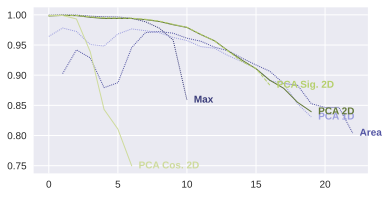

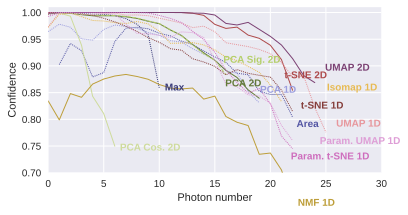

In [24]:
texts = []
objects = []
pad = 0.5
xlim = (0,30)
ylim = (0.7,1.01)
yscale = 'linear'
config = config_uniform
path_results = r'src/Results TES (Uniform)/'

cmap = mpl.colormaps['tab20b']
colors = cmap(np.linspace(0, 1, len(config.keys())))

with plt.style.context("seaborn-v0_8"):
        fig, ax = plt.subplots(figsize = (6,3))

        for index_method, (method, color) in enumerate(zip(config, colors)):

                method_dict = config[method]
                i, f = method_dict['n_photons']
                result = np.load(f'{path_results}/Confidence/{method}', allow_pickle=True)
                print(method)

                print(result.shape)
                confidence = result[:f]
                photon_number = np.arange(i,f+i)


                objects.append(ax.plot(photon_number, confidence, 
                                        c = color, 
                                        alpha=1, 
                                        linewidth = 1,
                                        linestyle = method_dict['line']))
  
                texts.append(ax.text(photon_number[-1]+pad, 
                                        confidence[-1], 
                                        method_dict['Name'], 
                                        color = color, 
                                        fontsize=10, 
                                        weight="bold", 
                                        va = "center"))
            
        adjust_text(texts = texts,
                    ax = ax, 
                    expand=(1.05, 1.2),
                    only_move = {"text": "xy", "static": "xy", "explode": "xy", "pull": "xy"},
                    ensure_inside_axes = False) 
        plt.ylabel('Confidence')
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.yscale(yscale)
        plt.xlabel('Photon number')
        plt.savefig(f'{path_results}Confidence.pdf', format='pdf', bbox_inches='tight')
        plt.show()

In [ ]:
texts = []
objects = []
pad = 0
#xlim = (0,25)
ylim = (0.95,1.1)
yscale = 'linear'
config = config_uniform
path_results = r'src/Results TES (Uniform)/'

cmap = mpl.colormaps['tab20b']
colors = cmap(np.linspace(0, 1, len(config.keys())))

with plt.style.context("seaborn-v0_8"):
        fig, ax = plt.subplots(figsize = (6,3))
        plt.rcParams["lines.markeredgewidth"] = 1

        for index_method, (method, color) in enumerate(zip(config, colors)):

                method_dict = config[method]
                g2_load = np.flip(np.load(f'{path_results}/g2/{method[:-4]}_g2.npy', allow_pickle=True))
                db_load = np.flip(np.load(f'{path_results}/g2/{method[:-4]}_db.npy', allow_pickle=True))
                average = [Average[dB.index(float(db_))] for db_ in db_load]
                print(method)

                plt.plot(average, g2_load, 
                        c = color, 
                        marker = 'x',
                        alpha=1, 
                        linewidth = 2,
                        linestyle = method_dict['line'],
                        label = method_dict['Name'])
  
                # texts.append(ax.text(db[-1], 
                #                         g2[-1], 
                #                         method_dict['Name'], 
                #                         color = color, 
                #                         fontsize=10, 
                #                         weight="bold", 
                #                         va = "center"))
            
        # adjust_text(texts = texts,
        #             ax = ax, 
        #             expand=(1.0, 0.4),
        #             only_move = {"text": "xy", "static": "xy", "explode": "xy", "pull": "xy"},
        #             ensure_inside_axes = False) 
        plt.ylabel('g2')
        #plt.xlim(xlim)
        plt.legend(ncol = 3)
        plt.ylim(ylim)
        plt.yscale(yscale)
        plt.xlabel('Mean Photon number')
        plt.savefig(f'{path_results}g2.pdf', format='pdf', bbox_inches='tight')
        plt.show()

MAX.npy
AREA.npy
PCA 1D.npy
PCA 2D.npy
KPCA Sig 2D.npy
KPCA Cos 2D.npy
NMF 1D 1D.npy
ISO 1D.npy
tSNE 1D.npy
tSNE 2D.npy
UMAP 1D.npy
UMAP 2D.npy
PTSNE 1D.npy
PUMAP 1D.npy


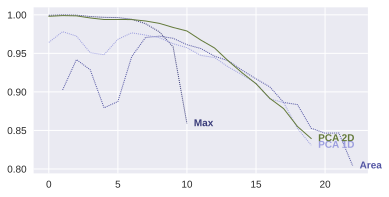

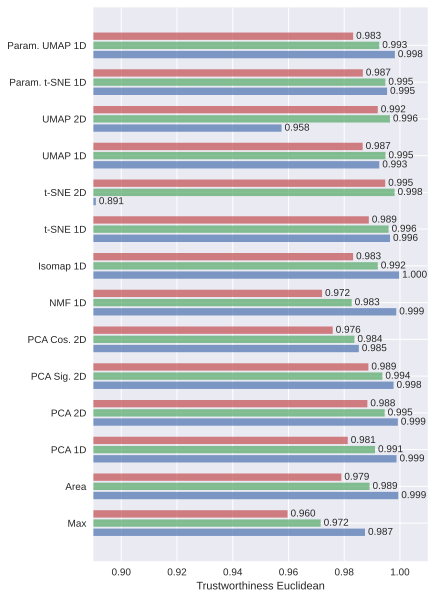

In [18]:
index_metric = 1
trust1 = []
trust2 = []
trust3 = []
name_method = []

for index_method, method in enumerate(config):

        method_dict = config[method]
        result = np.load(f'{path_results}/Trustworthiness Euclidian/{method}')
        print(method)
        trust1.append(result[-1])
        trust2.append(result[-2])
        trust3.append(result[-3])
        name_method.append(method_dict['Name'])

y_pos = np.arange(4*len(trust1))

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize = (6,10))
    ax = plt.gca()
    hbars1 = ax.barh(y_pos[0::4], trust1, align='center', alpha=0.7)
    hbars2 = ax.barh(y_pos[1::4], trust2, align='center', alpha=0.7)
    hbars3 = ax.barh(y_pos[2::4], trust3, align='center', alpha=0.7)
    ax.set_yticks(y_pos[1::4], labels=name_method)
    ax.bar_label(hbars1, fmt='%.3f', padding=3)
    ax.bar_label(hbars2, fmt='%.3f', padding=3)
    ax.bar_label(hbars3, fmt='%.3f', padding=3)
    ax.xaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.set_xlabel('Trustworthiness Euclidean')
    ax.set_xlim(0.89,1.01)
    plt.savefig(f'{path_results}Trustworthiness.pdf', format='pdf', bbox_inches='tight')
    plt.show()